In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
data = pd.read_csv("Students Social Media Addiction (1).csv")
data

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [3]:
# Dataset shape
print("Dataset Shape:", data.shape)

# Dataset information
data.info()

# Check missing values
data.isnull().sum()


Dataset Shape: (705, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-n

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

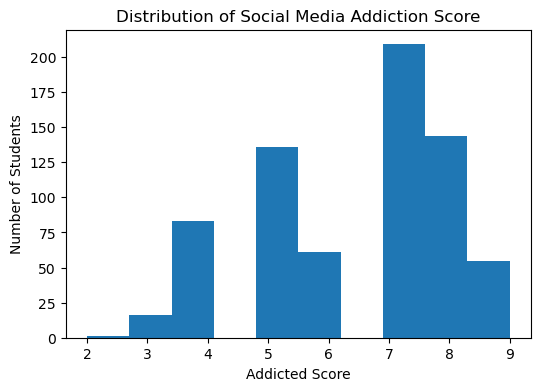

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data['Addicted_Score'], bins=10)
plt.xlabel("Addicted Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Social Media Addiction Score")
plt.show()


In [5]:
le = LabelEncoder()
data['Affects_Academic_Performance'] = le.fit_transform(
    data['Affects_Academic_Performance']
)

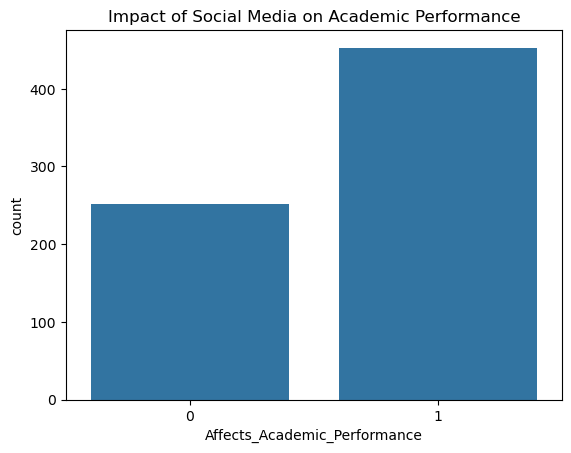

In [6]:
sns.countplot(x='Affects_Academic_Performance', data=data)
plt.title("Impact of Social Media on Academic Performance")
plt.show()

In [7]:
X = data[['Avg_Daily_Usage_Hours','Sleep_Hours_Per_Night', 'Mental_Health_Score']]
y = data['Affects_Academic_Performance']

In [8]:
X

,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,5.2,6.5,6
1,2.1,7.5,8
2,6.0,5.0,5
3,3.0,7.0,7
4,4.5,6.0,6
...,...,...,...
700,4.7,7.2,7
701,6.8,5.9,4
702,5.6,6.7,6
703,4.3,7.5,8


In [9]:
y

0      1
1      0
2      1
3      0
4      1
      ..
700    0
701    1
702    1
703    0
704    1
Name: Affects_Academic_Performance, Length: 705, dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic Regression

In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [12]:
y_pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9716312056737588
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        54
           1       1.00      0.95      0.98        87

    accuracy                           0.97       141
   macro avg       0.97      0.98      0.97       141
weighted avg       0.97      0.97      0.97       141



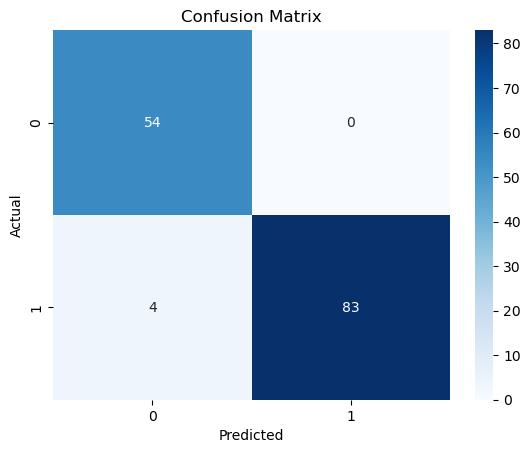

In [14]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

RANDOM FOREST

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
y_pred_rf = rf_model.predict(X_test)

In [18]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.9432624113475178


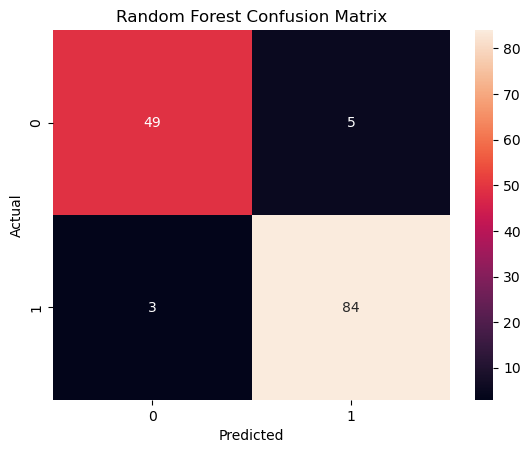

In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

DECISION TREE

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [22]:
y_pred_dt = dt_model.predict(X_test)

In [23]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9432624113475178


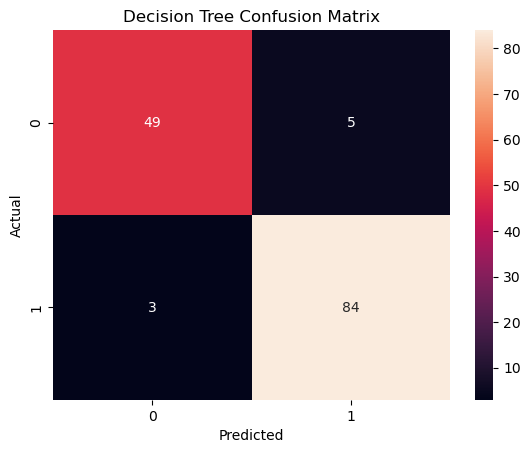

In [24]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KNN

In [25]:
from sklearn.neighbors import KNeighborsClassifier

In [26]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [27]:
y_pred_knn = knn_model.predict(X_test)

In [28]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9432624113475178


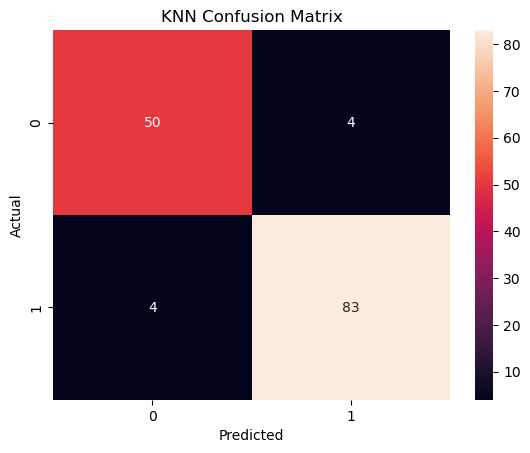

In [29]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
pip install gradio joblib

Note: you may need to restart the kernel to use updated packages.


In [31]:
import gradio as gr
import numpy as np
import joblib

# ----------------- LOAD MODEL & SCALER ----------------- #
model = joblib.load("rf_model.pkl")
scaler = joblib.load("scaler.pkl")

# ----------------- MAPPING CATEGORICAL INPUTS ----------------- #
gender_options = {"Female": 0, "Male": 1}
academic_levels = {"High School": 0, "Undergraduate": 1, "Postgraduate": 2}
countries = {"India": 0, "USA": 1, "Other": 2}
platforms = {"Instagram": 0, "Facebook": 1, "Twitter": 2, "Others": 3}

# ----------------- PREDICTION FUNCTION ----------------- #
def predict_addiction(
    age,
    gender,
    academic_level,
    country,
    daily_usage,
    sleep_hours,
    login_freq,
    platform,
    academic_effect,
    relationship,
    study_hours
):
    # Convert categorical inputs to numeric
    gender = gender_options[gender]
    academic_level = academic_levels[academic_level]
    country = countries[country]
    platform = platforms[platform]
    academic_effect_val = 1 if academic_effect == "Yes" else 0
    relationship_val = 1 if relationship == "In Relationship" else 0

    # Prepare data
    data = np.array([[
        age,
        gender,
        academic_level,
        country,
        daily_usage,
        sleep_hours,
        login_freq,
        platform,
        academic_effect_val,
        relationship_val,
        study_hours
    ]])
    
    data_scaled = scaler.transform(data)
    score = model.predict(data_scaled)[0]
    display_score = round(score, 2)

    # Healthy user logic
    healthy_user = (
        daily_usage <= 2 and
        sleep_hours >= 6 and
        login_freq <= 5 and
        academic_effect_val == 0 and
        study_hours >= 2
    )

    # Determine risk and color
    if healthy_user:
        result = "Low Addiction Risk"
        color = "#4CAF50"  # Green
    elif score < 6:
        result = "Moderate Addiction Risk"
        color = "#FFA500"  # Orange
    else:
        result = "High Addiction Risk"
        color = "#F44336"  # Red

    # HTML output with color bar
    html_output = f"""
    <div style='font-size:20px; font-weight:bold; margin-bottom:10px;'>
        Score: {display_score} → {result}
    </div>
    <div style='width:100%; background-color:#e0e0e0; height:30px; border-radius:5px;'>
        <div style='width:{min(display_score*10,100)}%; background-color:{color}; height:100%; border-radius:5px;'></div>
    </div>
    """
    return html_output

# ----------------- CLEAR FUNCTION ----------------- #
def clear_prediction():
    return ""  # Clears the output field

# ----------------- GRADIO INTERFACE ----------------- #
with gr.Blocks() as interface:
    gr.Markdown("## 📱 Social Media Addiction Predictor")
    gr.Markdown("Complete the form below to estimate your social media addiction risk.")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 👤 Personal Info")
            age = gr.Number(label="Age", value=18, info="Enter your age in years")
            gender = gr.Radio(list(gender_options.keys()), label="Gender", info="Select your gender")
            academic_level = gr.Dropdown(list(academic_levels.keys()), label="Academic Level", info="Select your highest academic level")
            country = gr.Dropdown(list(countries.keys()), label="Country", info="Select your country")
        
        with gr.Column():
            gr.Markdown("### 📊 Social Media Usage & Lifestyle")
            daily_usage = gr.Slider(0, 12, step=0.5, label="Daily Usage (Hours)", info="Hours spent on social media daily")
            sleep_hours = gr.Slider(0, 12, step=0.5, label="Sleep Hours", info="Average hours of sleep per day")
            login_freq = gr.Number(label="Login Frequency per Day", value=1, info="Times you log in daily")
            platform = gr.Dropdown(list(platforms.keys()), label="Most Used Platform", info="Your primary social media platform")
            academic_effect = gr.Radio(["No", "Yes"], label="Affects Academic Performance?", info="Has social media usage affected your studies?")
            relationship = gr.Radio(["Single", "In Relationship"], label="Relationship Status", info="Select your relationship status")
            study_hours = gr.Slider(0, 10, step=0.5, label="Daily Study Hours", info="Average study hours per day")
    
    with gr.Row():
        submit_btn = gr.Button("Predict Addiction Risk", variant="primary")
        reset_btn = gr.Button("Reset Inputs", variant="secondary")
        clear_btn = gr.Button("Clear Prediction", variant="secondary")  # <-- Clear button
    
    output = gr.HTML(label="Prediction Result")
    
    # Connect buttons
    submit_btn.click(
        fn=predict_addiction,
        inputs=[age, gender, academic_level, country, daily_usage, sleep_hours, login_freq, platform, academic_effect, relationship, study_hours],
        outputs=output
    )

    reset_btn.click(
        fn=lambda: (18, "Female", "High School", "India", 0, 8, 1, "Instagram", "No", "Single", 2),
        inputs=[],
        outputs=[age, gender, academic_level, country, daily_usage, sleep_hours, login_freq, platform, academic_effect, relationship, study_hours]
    )

    clear_btn.click(
        fn=clear_prediction,
        inputs=[],
        outputs=output
    )

interface.launch()


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
